In [5]:
from google.colab import files
uploaded = files.upload()

Saving ford.csv to ford.csv


Veri Setinin İlk 5 Satırı:


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0



Veri Seti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17965 entries, 0 to 17964
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17965 non-null  object 
 1   year          17965 non-null  int64  
 2   price         17965 non-null  int64  
 3   transmission  17965 non-null  object 
 4   mileage       17965 non-null  int64  
 5   fuelType      17965 non-null  object 
 6   tax           17965 non-null  int64  
 7   mpg           17965 non-null  float64
 8   engineSize    17965 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


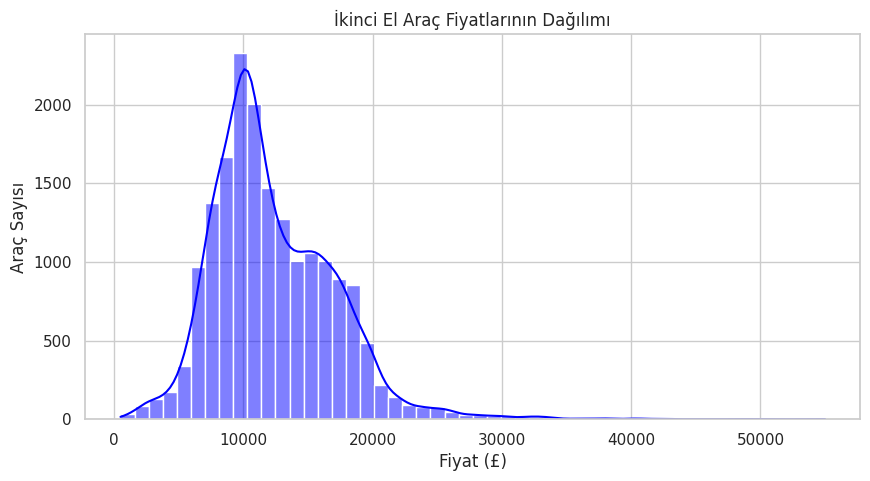

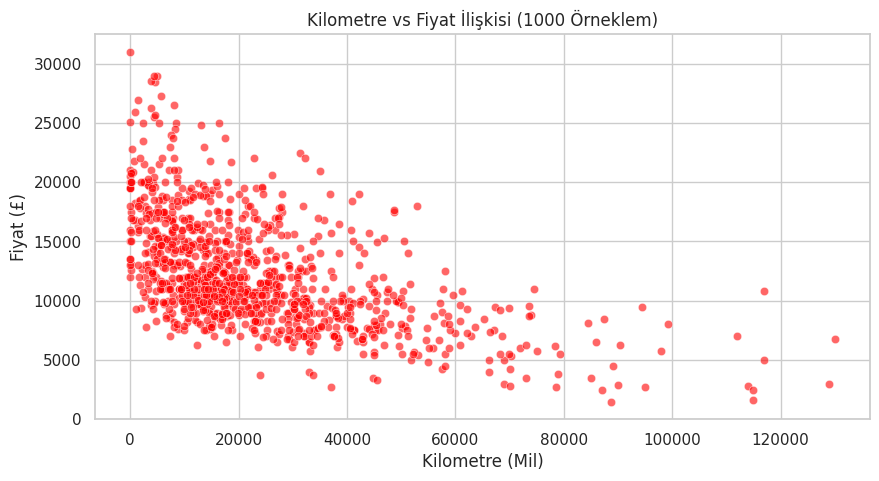

/tmp/ipykernel_876/3808894132.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='transmission', y='price', data=df, palette='Set2')


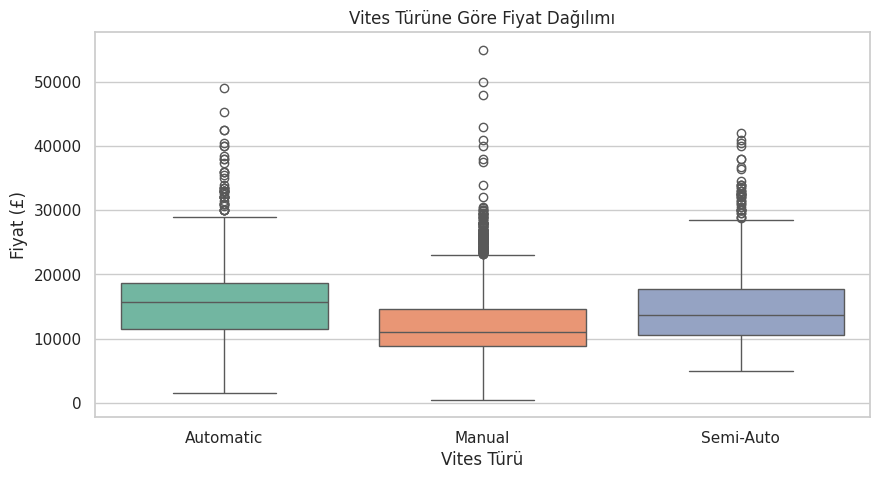

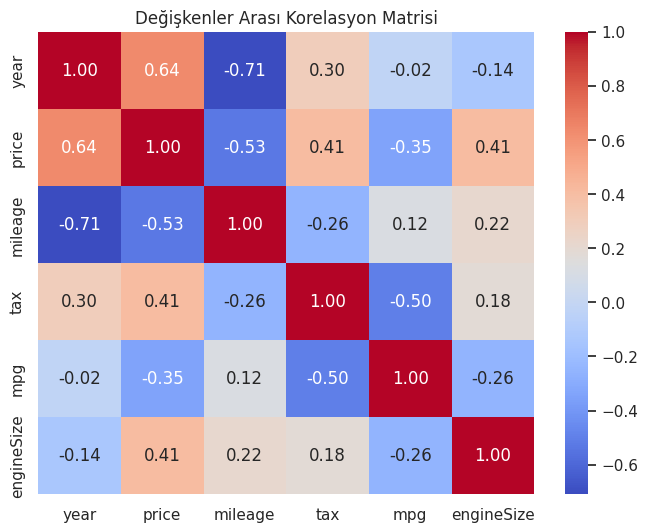

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Yükleme ve Genel Bakış
df = pd.read_csv('ford.csv')

print("Veri Setinin İlk 5 Satırı:")
display(df.head())

print("\nVeri Seti Bilgileri:")
df.info()

# Grafiklerin genel stilini belirleme
sns.set_theme(style="whitegrid")

# --- GÖRSELLEŞTİRME 1: Hedef Değişkenin (Fiyat) Dağılımı ---
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('İkinci El Araç Fiyatlarının Dağılımı')
plt.xlabel('Fiyat (£)')
plt.ylabel('Araç Sayısı')
plt.show()

# --- GÖRSELLEŞTİRME 2: Kilometre (Mileage) ve Fiyat İlişkisi ---
plt.figure(figsize=(10, 5))
# Görüntüyü temiz tutmak için rastgele 1000 örneklem (sample) alıyoruz
sns.scatterplot(x='mileage', y='price', data=df.sample(1000, random_state=42), alpha=0.6, color='red')
plt.title('Kilometre vs Fiyat İlişkisi (1000 Örneklem)')
plt.xlabel('Kilometre (Mil)')
plt.ylabel('Fiyat (£)')
plt.show()

# --- GÖRSELLEŞTİRME 3: Vites Türüne Göre Fiyat Dağılımı ---
plt.figure(figsize=(10, 5))
sns.boxplot(x='transmission', y='price', data=df, palette='Set2')
plt.title('Vites Türüne Göre Fiyat Dağılımı')
plt.xlabel('Vites Türü')
plt.ylabel('Fiyat (£)')
plt.show()

# --- GÖRSELLEŞTİRME 4: Sayısal Değişkenler Arası Korelasyon ---
plt.figure(figsize=(8, 6))
# Sadece sayısal sütunları seçip korelasyon matrisini çizdiriyoruz
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Değişkenler Arası Korelasyon Matrisi')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Eksik Değer Kontrolü
# Veri setinde boş değer (NaN) varsa bu satırları siliyoruz.
df = df.dropna()

# 2. Hedef (y) ve Özellik (X) Değişkenlerini Ayırma
# Amacımız 'price' tahmin etmek, bu yüzden price'ı çıkarıp hedefe koyuyoruz.
y = df['price']
X = df.drop('price', axis=1)

# 3. Kategorik Değişkenleri Sayısallaştırma (One-Hot Encoding)
# Makine metin anlayamaz (örn: 'Manual', 'Petrol').
# Bu sütunları pd.get_dummies ile 0 ve 1'lerden oluşan matematiksel formatlara çeviriyoruz.
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Eğitim ve Test Setlerine Bölme
# Modelin görmediği verideki başarısını ölçmek için verinin %80'ini eğitime, %20'sini teste ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 5. Ölçeklendirme (Scaling)
# Kilometre (örn: 60.000) ile motor hacmi (örn: 1.5) arasındaki devasa matematiksel uçurumu kapatmak için
# StandardScaler ile tüm sayısal değerleri aynı ölçeğe getiriyoruz.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Test setinde fit yapılmaz (Veri sızıntısını (data leakage) önlemek için)

print(f"Eğitim Seti Boyutu: {X_train_scaled.shape[0]} araç")
print(f"Test Seti Boyutu: {X_test_scaled.shape[0]} araç")
print("Veri ön işleme adımları başarıyla tamamlandı, veriler model eğitimine hazır!")

Eğitim Seti Boyutu: 14372 araç
Test Seti Boyutu: 3593 araç
Veri ön işleme adımları başarıyla tamamlandı, veriler model eğitimine hazır!


Linear Regression modeli eğitiliyor...
Random Forest modeli eğitiliyor (Bu birkaç saniye sürebilir)...

--- Model Karşılaştırma Tablosu ---


,Model,MAE (£),RMSE (£),R² Skoru
0,Linear Regression,1368.828863,1838.357462,0.848981
1,Random Forest,860.472964,1253.818730,0.929751


/tmp/ipykernel_876/1886029675.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Derecesi', y='Özellik', data=importance_df, palette='viridis')


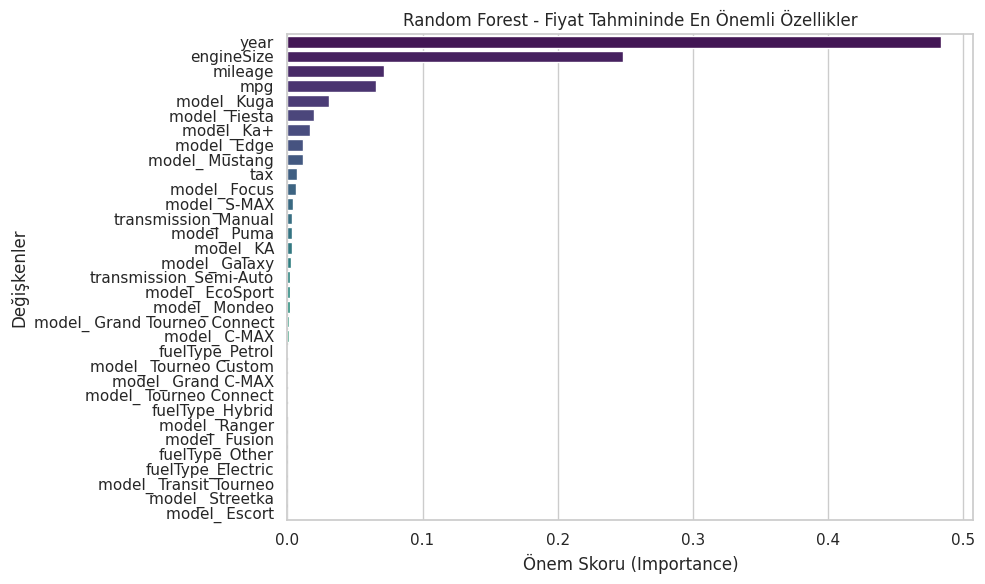

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. MODEL SEÇİMİ VE EĞİTİMİ ---

# Temel Model: Linear Regression (Doğrusal Regresyon)
print("Linear Regression modeli eğitiliyor...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

# Gelişmiş Model: Random Forest Regressor (Rastgele Orman)
# n_estimators=100 parametresi, ormanın 100 adet karar ağacından oluşacağını belirtir
print("Random Forest modeli eğitiliyor (Bu birkaç saniye sürebilir)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

# --- 2. MODEL DEĞERLENDİRME ---

# Metrikleri hesaplayan yardımcı bir fonksiyon
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "MAE (£)": mae, "RMSE (£)": rmse, "R² Skoru": r2}

# Sonuçları hesaplayıp tabloya dönüştürme
lr_results = evaluate_model(y_test, lr_predictions, "Linear Regression")
rf_results = evaluate_model(y_test, rf_predictions, "Random Forest")

results_df = pd.DataFrame([lr_results, rf_results])
print("\n--- Model Karşılaştırma Tablosu ---")
display(results_df)

# --- 3. ÖZELLİK ÖNEMİ (FEATURE IMPORTANCE) GÖRSELLEŞTİRMESİ ---
# Random Forest'in fiyatı tahmin ederken hangi değişkenlere (yıl, km vb.) daha çok önem verdiğini bulalım.

# Özellik isimlerini (feature_names) ve önem skorlarını (feature_importances_) alıyoruz
features = X_encoded.columns
importances = rf_model.feature_importances_

# Bunları bir DataFrame'de birleştirip büyükten küçüğe sıralıyoruz
importance_df = pd.DataFrame({'Özellik': features, 'Önem Derecesi': importances})
importance_df = importance_df.sort_values(by='Önem Derecesi', ascending=False)

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Derecesi', y='Özellik', data=importance_df, palette='viridis')
plt.title('Random Forest - Fiyat Tahmininde En Önemli Özellikler')
plt.xlabel('Önem Skoru (Importance)')
plt.ylabel('Değişkenler')
plt.tight_layout()
plt.show()

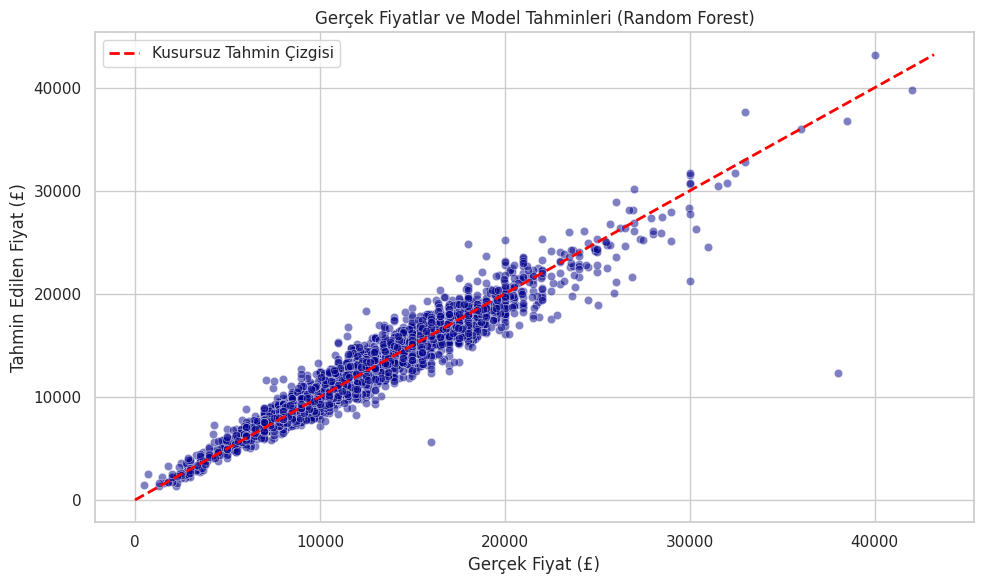


--- Modelin En Çok Hata Yaptığı 5 Araç ---


,Gerçek Fiyat,Tahmin Edilen Fiyat,Hata (Kalıntı),Mutlak Hata
1039,38015,12286.78,25728.22,25728.22
14743,15999,5656.42,10342.58,10342.58
7229,30000,21276.46,8723.54,8723.54
14384,17999,24795.79,-6796.79,6796.79
10958,30999,24517.18,6481.82,6481.82


In [9]:
# --- 4. HATA ANALİZİ (ERROR ANALYSIS) ---
# Random Forest modelinin gerçek değerler ile ne kadar saptığını (residual) inceliyoruz.

# Gerçek, tahmin edilen ve hata değerlerini bir tabloda birleştirelim
analysis_df = pd.DataFrame({
    'Gerçek Fiyat': y_test,
    'Tahmin Edilen Fiyat': rf_predictions
})
analysis_df['Hata (Kalıntı)'] = analysis_df['Gerçek Fiyat'] - analysis_df['Tahmin Edilen Fiyat']
analysis_df['Mutlak Hata'] = analysis_df['Hata (Kalıntı)'].abs()

# GÖRSELLEŞTİRME 1: Gerçek vs Tahmin Dağılımı
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Gerçek Fiyat', y='Tahmin Edilen Fiyat', data=analysis_df, alpha=0.5, color='darkblue')

# Mükemmel tahmin çizgisini (y=x) çizelim
max_val = max(analysis_df['Gerçek Fiyat'].max(), analysis_df['Tahmin Edilen Fiyat'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Kusursuz Tahmin Çizgisi')

plt.title('Gerçek Fiyatlar ve Model Tahminleri (Random Forest)')
plt.xlabel('Gerçek Fiyat (£)')
plt.ylabel('Tahmin Edilen Fiyat (£)')
plt.legend()
plt.tight_layout()
plt.show()

# En çok yanıldığımız 5 aracı gösterelim
print("\n--- Modelin En Çok Hata Yaptığı 5 Araç ---")
display(analysis_df.sort_values(by='Mutlak Hata', ascending=False).head(5))